# Generate the result in RQ1

This script generates the results presented in the RQ1 section of the paper. The script reads the data from the `data/rq1-discovery-probability` folder and generates the results presented in the paper. The figures are saved in the `figures` folder.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import multiprocessing as mp
import re
from scipy.stats import wilcoxon

# Directory where the coverage records are stored
directory = "data/rq1-discovery-probability"
fig_dir = "figures"

/home/nfs0/seongmin.lee/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Helper functions

In [2]:
# Record class
# exec_per_time: the average number of executions per time unit during the
#                fuzzing campaign
# p_emp_min: the minimum value of the empirical discovery probability
# data_done: the coverage records
@dataclass
class Record:
    exec_per_time: float
    p_emp_min: float
    data_done: pd.DataFrame

# Parse the record file and return a Record object
def get_record_obj(data_path):
    data = pd.read_csv(data_path, sep=", ", engine="python")
    data["done"] = data["done"].astype(bool)
    data["time"] = data["time"] / 1000 / 60
    # if #singletons or #sglt_clusts is 0, set it to 1
    data["#singletons"] = data["#singletons"].replace(0, 1)
    data["#sglt_clusts"] = data["#sglt_clusts"].replace(0, 1)
    data_done = data[data["done"]]
    # cut off the data after 24 hours
    data_done = data_done[data_done["time"] < 24 * 60]
    row_last = data_done.iloc[-1]
    last_index = data_done.index[-1]
    # Add a row for 24 hours
    if last_index + 1 < len(data):
        row_last_plus1 = data.iloc[last_index + 1]
        row_24h = {
            "time": 24 * 60.0,
            "#execs": row_last["#execs"]
                + (row_last_plus1["#execs"] - row_last["#execs"])
                * (24 * 60 - row_last["time"])
                / (row_last_plus1["time"] - row_last["time"]),
            "#covered": row_last["#covered"],
            "#singletons": row_last["#singletons"],
            "#sglt_clusts": row_last["#sglt_clusts"],
            "#foundnew": row_last["#foundnew"],
            "done": True,
            "update?": False,
        }
        data_done = pd.concat(
            [data_done, pd.DataFrame([row_24h])], ignore_index=True
        )
    data_done.loc[:, "#execs"] = data_done["#execs"].astype(int)

    exec_per_time = data_done.iloc[-1]["#execs"] / data_done.iloc[-1]["time"]
    p_emps = data_done["#foundnew"] / data_done["#execs"]
    p_emps_min = np.min(p_emps[p_emps > 0])

    return Record(exec_per_time, p_emps_min, data_done)


# Given the time t_m, get the empirical discovery probability and
# the discovery probability estimated by the Good-Turing estimator (GT) and
# our dependenc-aware estimator (Chao)
def discovery(
    record_obj: Record, t_m: float, target: str, debug: bool = False
) -> float:
    exec_at_t = int(t_m * record_obj.exec_per_time)
    if exec_at_t == 0:
        return 0
    # find the row where #execs is the closest to exec_at_t
    for i, row in record_obj.data_done.iterrows():
        if row["#execs"] > exec_at_t:
            break
    row = record_obj.data_done.iloc[i - 1]
    assert row["done"]
    if debug:
        print(row)
    if target == "GT":
        ret = row["#singletons"] / exec_at_t
    elif target == "Chao":
        ret = row["#sglt_clusts"] / exec_at_t
    elif target == "emp":
        ret = row["#foundnew"] / exec_at_t
        if ret == 0:
            ret = record_obj.p_emp_min
    else:
        raise ValueError(f"Invalid target: {target}")
    return ret


# Get the analyzable format of the estimation results
def get_plot_df(
    record_obj: Record, x_scale: str, id: str
) -> pd.DataFrame:
    if x_scale == "lin":
        x = np.linspace(0, 24 * 60, 1000)
    elif x_scale == "log":
        x = np.logspace(0, np.log10(24 * 60), 1000)
    else:
        raise ValueError(f"Invalid x_scale: {x_scale}")
    print(f"{id=} processing start", flush=True, end="\r")
    y_emp = [discovery(record_obj, t, "emp") for t in x]
    print(f"{id=} emp done", flush=True, end="\r")
    y_GT = [discovery(record_obj, t, "GT") for t in x]
    print(f"{id=} GT done", flush=True, end="\r")
    y_Chao = [discovery(record_obj, t, "Chao") for t in x]
    print(f"{id=} Chao done", flush=True, end="\r")
    plot_df = pd.DataFrame(
        {"time": x, "p_emp": y_emp, "p_GT": y_GT, "p_Chao": y_Chao}
    )
    plot_df = plot_df.melt(
        id_vars=["time"], value_vars=["p_emp", "p_GT", "p_Chao"], value_name="Pr", var_name="Esti"
    )
    print(f"{id=} done", flush=True)
    plot_df["id"] = id
    return plot_df

In [3]:
# Read fuzzer_stats.csv files, which contains the summary of the
# fuzzing campaign, to get the repetition information
def read_fuzzer_stats(directory):
    """Reads the fuzzer_stats.csv file from the given directory."""
    file_path = os.path.join(directory, "fuzzer_stats.csv")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)
    return df


def count_indices_for_subject(df, subject):
    """Returns the number of unique indices for a given subject."""
    if "subject" not in df.columns or "index" not in df.columns:
        raise ValueError(
            "DataFrame must contain 'subject' and 'index' columns."
        )

    return sorted(
        [int(i) for i in df[df["subject"] == subject]["index"].unique()]
    )

## Parse the record to generate the data for analysis

In [4]:
# get list of records and subjects in this directory
datas = [
    data
    for data in os.listdir(os.path.join(directory, "records"))
    if data.endswith("_records.csv")
]
subjects = np.unique([data.split("_")[0] for data in datas]).tolist()
print(f"subjects: {subjects}")

subjects: ['freetype2', 'jsoncpp', 'libjpeg', 'libpcap', 'libpng', 'libxml2', 'sqlite3', 'zlib']


In [5]:
# check the number of unique repetition indices for each subject
df_fuzzer_stats = read_fuzzer_stats(directory)

for subject_name in subjects:
    index_count = count_indices_for_subject(df_fuzzer_stats, subject_name)
    print(
        f"Number of unique indices for subject '{subject_name}': {index_count}"
    )

Number of unique indices for subject 'freetype2': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'jsoncpp': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'libjpeg': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'libpcap': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'libpng': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'libxml2': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'sqlite3': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique indices for subject 'zlib': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [ ]:
# Generate data for each record and store it in the data directory
# the data is stored in the format of {subject}.csv
# This takes a while to generate the data (~10 minutes)
# If the data already exists, you can skip this step by setting is_generate
# to False.
is_generate = True
for subject in subjects:
    if is_generate or not os.path.exists(
        os.path.join(directory, f"records/{subject}.csv")
    ):
        print(f"Generating data for {subject}")
        idcs = count_indices_for_subject(df_fuzzer_stats, subject)
        print(
            [
                os.path.join(directory, f"records/{subject}_{i}_records.csv")
                for i in idcs
            ]
        )
        with mp.Pool(len(idcs)) as pool:
            record_objs = pool.map(
                get_record_obj,
                [
                    os.path.join(
                        directory, f"records/{subject}_{i}_records.csv"
                    )
                    for i in idcs
                ],
            )
        params = [
            (record_obj, "log", str(idx))
            for idx, record_obj in enumerate(record_objs, 1)
        ]
        with mp.Pool(len(params)) as pool:
            plot_dfs = pool.starmap(get_plot_df, params)
        plot_df = pd.concat(plot_dfs, ignore_index=True)
        plot_df["Esti"] = plot_df["Esti"].replace(
            {
                "p_emp": r"$\hat{m}_{emp}$",
                "p_GT": r"$\hat{m}_{GT}$",
                "p_Chao": r"$\hat{m}_{St}$",
            }
        )
        # save plot_df
        plot_df.to_csv(
            os.path.join(directory, "records/", f"{subject}.csv"), index=False
        )

Generating data for freetype2
['data/rq1-dp/records/freetype2_0_records.csv', 'data/rq1-dp/records/freetype2_1_records.csv', 'data/rq1-dp/records/freetype2_2_records.csv', 'data/rq1-dp/records/freetype2_3_records.csv', 'data/rq1-dp/records/freetype2_4_records.csv', 'data/rq1-dp/records/freetype2_5_records.csv', 'data/rq1-dp/records/freetype2_6_records.csv', 'data/rq1-dp/records/freetype2_7_records.csv', 'data/rq1-dp/records/freetype2_8_records.csv', 'data/rq1-dp/records/freetype2_9_records.csv', 'data/rq1-dp/records/freetype2_10_records.csv', 'data/rq1-dp/records/freetype2_11_records.csv', 'data/rq1-dp/records/freetype2_12_records.csv', 'data/rq1-dp/records/freetype2_13_records.csv', 'data/rq1-dp/records/freetype2_14_records.csv', 'data/rq1-dp/records/freetype2_15_records.csv', 'data/rq1-dp/records/freetype2_16_records.csv', 'data/rq1-dp/records/freetype2_17_records.csv', 'data/rq1-dp/records/freetype2_18_records.csv', 'data/rq1-dp/records/freetype2_19_records.csv']
id='9' done doneng 

## Discovery probability estimation accuracy (RQ1-1.)

It generates
- Overall discovery probability estimation accuracy (Table 1 in the main paper)
- Discovery probability estimation accuracy at each time interval (Table 1 in the supplementary material)
- Boxplot of the discovery probability estimation at each time interval (Figure 5 in the main paper)
- Line plot of the empirical discovery probability and the estimated discovery probability (Figure 4 in the main paper and Figure 1 in the supplementary material)

In [7]:
# Aggregate the data
data = []
for subject in subjects:
    plot_df = pd.read_csv(os.path.join(directory, f"records/{subject}.csv"))
    sub_df = plot_df[["id", "time", "Esti", "Pr"]]
    for id in sub_df["id"].unique():
        sub_sub_df = sub_df[sub_df["id"] == id].copy()
        sub_sub_df["Esti"] = sub_sub_df["Esti"].replace(
            {
                r"$\hat{m}_{emp}$": "emp",
                r"$\hat{m}_{GT}$": "GT",
                r"$\hat{m}_{St}$": "Chao",
            }
        )
        sub_sub_df = (
            sub_sub_df.pivot(index="time", columns="Esti", values="Pr")
            .reset_index()
            .rename_axis(None, axis=1)
        )
        # display(sub_sub_df)
        # break
        sub_sub_df["err_gt"] = np.abs(sub_sub_df["GT"] - sub_sub_df["emp"])
        sub_sub_df["err_chao"] = np.abs(sub_sub_df["Chao"] - sub_sub_df["emp"])
        sub_sub_df["rel_err_gt"] = sub_sub_df["err_gt"] / sub_sub_df["emp"]
        sub_sub_df["rel_err_chao"] = sub_sub_df["err_chao"] / sub_sub_df["emp"]

        time_intervals = [(1, 10), (10, 60), (60, 360), (360, 1440), (1, 1440)]
        for start_time, end_time in time_intervals:
            time_id = f"{start_time}-{end_time}"
            sub3_df = sub_sub_df[
                (sub_sub_df["time"] >= start_time)
                & (sub_sub_df["time"] <= end_time)
            ]
            time_diff = sub3_df["time"].diff().dropna()
            mid = lambda x: (x.iloc[1:] + x.iloc[:-1]) / 2
            weighted_avg = lambda x: np.sum(x.iloc[1:] * time_diff) / np.sum(
                time_diff
            )
            emp_avg = weighted_avg(mid(sub3_df["emp"]))
            err_gt_avg = weighted_avg(mid(sub3_df["err_gt"]))
            err_chao_avg = weighted_avg(mid(sub3_df["err_chao"]))
            rel_err_gt_avg = weighted_avg(mid(sub3_df["rel_err_gt"]))
            rel_err_chao_avg = weighted_avg(mid(sub3_df["rel_err_chao"]))
            data.append(
                {
                    "subject": subject,
                    "id": id,
                    "interval": time_id,
                    "emp_avg": emp_avg,
                    "err_gt_avg": err_gt_avg,
                    "err_chao_avg": err_chao_avg,
                    "rel_err_gt_avg": rel_err_gt_avg,
                    "rel_err_chao_avg": rel_err_chao_avg,
                }
            )
data_df = pd.DataFrame(data)
# assign very small value to 0 values
data_df.replace(0, 1e-20, inplace=True)
data_df

,subject,id,interval,emp_avg,err_gt_avg,err_chao_avg,rel_err_gt_avg,rel_err_chao_avg
0,freetype2,1,1-10,2.492632e-03,7.946951e-03,3.072730e-04,3.035141,0.132632
1,freetype2,1,10-60,3.599359e-04,5.907679e-04,7.550037e-05,1.508871,0.228127
2,freetype2,1,60-360,4.858996e-05,1.080611e-04,7.179315e-06,2.465830,0.164348
3,freetype2,1,360-1440,1.206427e-05,3.719891e-05,1.817388e-06,3.276111,0.143158
4,freetype2,1,1-1440,4.766212e-05,1.215968e-04,7.434482e-06,3.048834,0.150624
...,...,...,...,...,...,...,...,...
795,zlib,20,1-10,3.563978e-05,4.405837e-05,1.602121e-05,1.843109,0.573074
796,zlib,20,10-60,4.198808e-06,4.859576e-06,2.556087e-06,2.343741,1.485747
797,zlib,20,60-360,2.927472e-07,5.014935e-07,1.942345e-07,1.636951,0.670604
798,zlib,20,360-1440,8.741382e-08,2.968330e-08,3.030657e-08,0.349446,0.356500


#### Overall discovery probability estimation accuracy (Table 1 in the main paper)

In [8]:
# average the data across repetitions
data_df_avg = (
    data_df.replace([np.inf, -np.inf], np.nan)
    .dropna()
    .groupby(["subject", "interval"])
    .mean()
    .reset_index()
)
data_df_avg["ratio"] = (
    data_df_avg["err_chao_avg"] / data_df_avg["err_gt_avg"]
)
data_df_avg["interval"] = pd.Categorical(
    data_df_avg["interval"],
    categories=["1-10", "10-60", "60-360", "360-1440", "1-1440"],
    ordered=True,
)
data_df_avg = data_df_avg.sort_values(["subject", "interval"])

In [9]:
total_df_avg = data_df_avg[data_df_avg["interval"] == "1-1440"]
total_df_avg = total_df_avg[
    [
        "subject",
        "emp_avg",
        "err_gt_avg",
        "err_chao_avg",
        "rel_err_gt_avg",
        "rel_err_chao_avg",
        "ratio",
    ]
]
# sort based on the ratio
total_df_avg = total_df_avg.sort_values("ratio")
# change the name of the columns
total_df_avg.columns = [
    "Subject",
    r"$\hat{m}_{\mathit{emp}}$",
    r"$\mathit{AE}_{G}$",
    r"$\mathit{AE}_{D}$",
    r"$\mathit{RE}_{G}$",
    r"$\mathit{RE}_{D}$",
    r"$\frac{\mathit{AE}_{D}}{\mathit{AE}_{G}}$",
]
total_df_avg = total_df_avg.reset_index(drop=True)

In [10]:
# Add statistical test result
total_df = data_df[data_df["interval"] == "1-1440"]

# Create a list to store results
results = []

# Group by 'subject'
for subject, group in total_df.groupby("subject"):
    err_gt_avg = group["err_gt_avg"].values
    err_chao_avg = group["err_chao_avg"].values

    # Wilcoxon signed-rank test
    try:
        stat, p_value = wilcoxon(
            err_gt_avg, err_chao_avg, alternative="two-sided"
        )
    except ValueError:  # Handle cases where values are identical
        stat, p_value = np.nan, np.nan

    # Compute effect size
    delta = 1 - 2 * stat / (len(err_gt_avg) * (len(err_gt_avg) + 1))
    magnitude = ""
    if delta < 0.1:
        magnitude = "negligible"
    elif delta < 0.3:
        magnitude = "small"
    elif delta < 0.5:
        magnitude = "medium"
    else:
        magnitude = "large"

    # Append results
    results.append(
        {
            "Subject": subject,
            "wilcoxon_stat": stat,
            r"$p$": f"{p_value:.0e}",
            # r"$\delta$": f"{delta:.2f} ({magnitude[0].upper()})",
            r"$\delta$": f"{delta:.2f}",
            # "effect_size": magnitude,
        }
    )

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# append 'only' p_value and effect size to total_df_avg
total_df_avg_merged = pd.merge(
    total_df_avg, results_df[["Subject", r"$p$", r"$\delta$"]], on="Subject"
)

In [11]:
# we use scientific notation for AE, .2f for RE, and .2f for RE ratio
# Convert numeric values to scientific notation in columns 1 and 2
# Convert to string type explicitly to avoid dtype conflicts
total_df_avg_merged = total_df_avg_merged.astype(str)

# Convert columns 1-2 to scientific notation (2 decimal places)
total_df_avg_merged.iloc[:, 1:4] = total_df_avg_merged.iloc[:, 1:4].map(
    lambda x: f"{float(x):.2e}"
)

# Convert columns 3-5 to standard decimal format (2 decimal places)
total_df_avg_merged.iloc[:, 4:6] = total_df_avg_merged.iloc[:, 4:6].map(
    lambda x: f"{float(x):.2f}"
)

# Convert column 6 to 2 decimal places
total_df_avg_merged.iloc[:, 6] = total_df_avg_merged.iloc[:, 6].map(
    lambda x: f"{float(x):.2f}"
)

# Display the DataFrame
display(total_df_avg_merged)

# print the average of 

,Subject,$\hat{m}_{\mathit{emp}}$,$\mathit{AE}_{G}$,$\mathit{AE}_{D}$,$\mathit{RE}_{G}$,$\mathit{RE}_{D}$,$\frac{\mathit{AE}_{D}}{\mathit{AE}_{G}}$,$p$,$\delta$
0,sqlite3,1.01e-04,1.02e-03,1.69e-05,8.50,0.14,0.02,2e-06,1.00
1,freetype2,5.38e-05,1.45e-04,9.41e-06,3.85,0.20,0.07,2e-06,1.00
2,libxml2,2.95e-04,4.13e-04,3.11e-05,0.71,0.11,0.08,2e-06,1.00
3,libjpeg,2.29e-06,5.56e-06,7.45e-07,2.09,0.46,0.13,2e-06,1.00
4,zlib,3.61e-07,6.80e-07,1.70e-07,2.55,1.48,0.25,2e-06,1.00
5,libpcap,2.76e-08,9.38e-08,3.25e-08,15.87,4.71,0.35,2e-04,0.99
6,jsoncpp,1.91e-07,1.45e-07,1.03e-07,1.26,0.94,0.71,1e-05,0.99
7,libpng,1.84e-06,1.33e-06,1.27e-06,1.62,1.10,0.95,4e-04,0.92


#### Discovery probability estimation accuracy at each time interval (Table 1 in the supplementary material)

In [12]:
data_df_sup = data_df_avg[~data_df_avg["interval"].isin(["1-1440"])]
data_df_sup = data_df_sup[
    [
        "subject",
        "interval",
        "emp_avg",
        "err_gt_avg",
        "err_chao_avg",
        "rel_err_gt_avg",
        "rel_err_chao_avg",
        "ratio",
    ]
]
# sort based on the subject order in data_df_sup
data_df_sup["subject"] = pd.Categorical(
    data_df_sup["subject"],
    categories=total_df_avg["Subject"].values.tolist(),
    ordered=True,
)
data_df_sup["interval"] = pd.Categorical(
    data_df_sup["interval"],
    categories=["1-10", "10-60", "60-360", "360-1440"],
    ordered=True,
)
data_df_sup = data_df_sup.sort_values(["subject", "interval"])
# # change the name of the columns
data_df_sup.columns = [
    "Subject",
    "Interval (min)",
    r"$\hat{m}_{\mathit{emp}}$",
    r"$\mathit{AE}_{G}$",
    r"$\mathit{AE}_{D}$",
    r"$\mathit{RE}_{G}$",
    r"$\mathit{RE}_{D}$",
    r"$\frac{\mathit{AE}_{D}}{\mathit{AE}_{G}}$",
]
data_df_sup = data_df_sup.reset_index(drop=True)
# data_df_sup
# we use scientific notation for AE, .2f for RE, and .2f for RE ratio
# Convert numeric values to scientific notation in columns 1 and 2
# Convert to string type explicitly to avoid dtype conflicts
data_df_sup = data_df_sup.astype(str)

# Convert columns 1-2 to scientific notation (2 decimal places)
data_df_sup.iloc[:, 2:5] = data_df_sup.iloc[:, 2:5].map(
    lambda x: f"{float(x):.2e}"
)

# Convert columns 3-5 to standard decimal format (2 decimal places)
data_df_sup.iloc[:, 5:8] = data_df_sup.iloc[:, 5:8].map(
    lambda x: f"{float(x):.2f}"
)

# Display the DataFrame
display(data_df_sup)

,Subject,Interval (min),$\hat{m}_{\mathit{emp}}$,$\mathit{AE}_{G}$,$\mathit{AE}_{D}$,$\mathit{RE}_{G}$,$\mathit{RE}_{D}$,$\frac{\mathit{AE}_{D}}{\mathit{AE}_{G}}$
0,sqlite3,1-10,1.59e-03,2.93e-02,4.98e-04,16.05,0.34,0.02
1,sqlite3,10-60,4.29e-04,4.56e-03,1.10e-04,11.34,0.27,0.02
2,sqlite3,60-360,1.53e-04,1.57e-03,1.99e-05,10.13,0.13,0.01
3,sqlite3,360-1440,5.83e-05,4.65e-04,7.63e-06,7.82,0.13,0.02
4,freetype2,1-10,3.01e-03,7.72e-03,4.87e-04,2.64,0.17,0.06
5,freetype2,10-60,3.87e-04,7.05e-04,6.46e-05,1.94,0.17,0.09
6,freetype2,60-360,5.49e-05,1.53e-04,1.15e-05,3.27,0.24,0.08
7,freetype2,360-1440,1.29e-05,5.19e-05,2.21e-06,4.10,0.18,0.04
8,libxml2,1-10,1.71e-02,3.46e-02,1.76e-03,1.83,0.11,0.05
9,libxml2,10-60,2.21e-03,2.87e-03,2.23e-04,1.28,0.10,0.08


### Boxplot of the discovery probability estimation at each time interval (Figure 5 in the main paper)

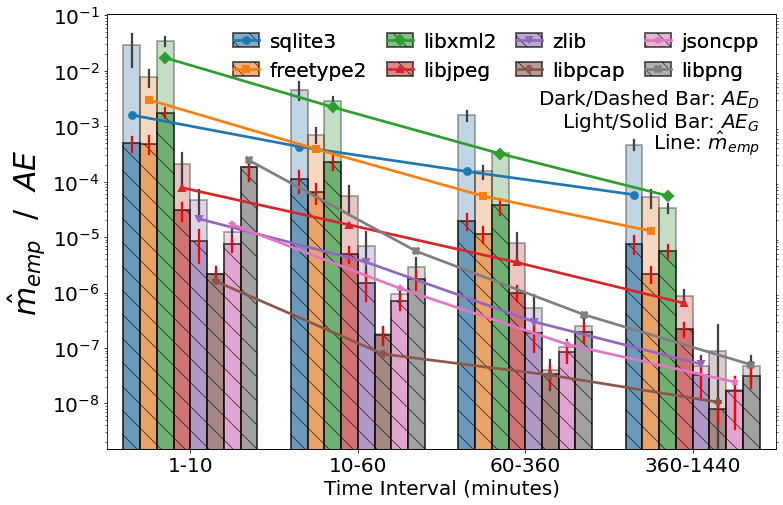

In [13]:
# Number of subjects
num_subjects = len(data_df["subject"].unique())
data_df_not_total = data_df[data_df["interval"] != "1-1440"].copy()
data_df_not_total["interval"] = pd.Categorical(
    data_df_not_total["interval"],
    categories=["1-10", "10-60", "60-360", "360-1440"],
    ordered=True,
)

# get the subject order from total_df_avg
subject_order = total_df_avg["Subject"].tolist()
data_df_not_total["subject"] = pd.Categorical(
    data_df_not_total["subject"],
    categories=subject_order,
    ordered=True,
)
bar_dodge_value = 0.8 * (num_subjects - 1) / num_subjects

# Plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Create a second y-axis for the bar plots
ax2 = ax1.twinx()

sns.barplot(
    data=data_df_not_total,
    x="interval",
    y="err_gt_avg",
    hue="subject",
    ax=ax1,
    errorbar="sd",
    alpha=0.3,
    edgecolor="black",
    linewidth=2,
    dodge=True,
)

sns.barplot(
    data=data_df_not_total,
    x="interval",
    y="err_chao_avg",
    hue="subject",
    ax=ax1,
    errorbar="sd",
    alpha=0.6,
    edgecolor="black",
    err_kws={'color': 'red'},
    linewidth=2,
    dodge=True,
)

# Apply slashed hatching only to the bars for ax2
for i, bar in enumerate(ax1.patches):
    if i < len(ax1.patches) // 2:
        continue
    else:
        bar.set_hatch("\\")

data_df_avg_not_total = data_df_avg[data_df_avg["interval"] != "1-1440"].copy()
data_df_avg_not_total["interval"] = pd.Categorical(
    data_df_avg_not_total["interval"],
    categories=["1-10", "10-60", "60-360", "360-1440"],
    ordered=True,
)
data_df_avg_not_total["subject"] = pd.Categorical(
    data_df_avg_not_total["subject"],
    categories=subject_order,
    ordered=True,
)
# Line plot using pointplot to align with barplots
sns.pointplot(
    data=data_df_avg_not_total,
    x="interval",
    y="emp_avg",
    hue="subject",
    ax=ax2,
    dodge=bar_dodge_value,
    # different markers for different subjects
    markers=["o", "s", "D", "^", "v", "P", "*", "X"],
)

# Remove the legend for rel_err_gt_avg
handles, labels = ax1.get_legend_handles_labels()
# two column legend
ax1.legend(
    handles[len(subjects) :],
    labels[len(subjects) :],
    title="",
    fontsize=20,
    # loc="upper center", bbox_to_anchor=(0.5, 1.2),
    ncol=4,
    columnspacing=1,
    labelspacing=0.5,
    handletextpad=0.5,
    handlelength=1.3,
    frameon=False,
)

ax1.set_ylabel(r"$\hat{m}_{\mathit{emp}}$  /  $\mathit{AE}$", fontsize=30)
ax1.tick_params(axis="y", labelsize=20)
ax1.set_yscale("log")
ax1.set_xlabel("Time Interval (minutes)", fontsize=20)
ax1.set_xticks(range(4))
ax1.set_xticklabels(["1-10", "10-60", "60-360", "360-1440"], fontsize=20)
ax2.legend(
    title="",
    fontsize=20,
    # loc="upper center", bbox_to_anchor=(0.5, 1.2),
    ncol=4,
    columnspacing=1,
    labelspacing=0.5,
    handletextpad=0.5,
    handlelength=1.3,
    frameon=False,
)

# set ax2 y-axis the same as ax1
ax2.set_ylim(ax1.get_ylim())
ax2.set_yscale("log")
# no ax2 y-axis label
ax2.set_ylabel("")
ax2.tick_params(labelright="off")
ax2.grid(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_yticks([])
ax2.set_yticklabels([])

# add text that Dark/Dashed is $\mathit{AE}_{D}$ and Light/Solid is $\mathit{AE}_{G}$
ax1.text(
    0.975,
    0.79,
    r"Dark/Dashed Bar: $\mathit{AE}_{D}$",
    fontsize=20,
    # right align
    horizontalalignment="right",
    transform=ax1.transAxes,
)
ax1.text(
    0.975,
    0.74,
    r"Light/Solid Bar: $\mathit{AE}_{G}$",
    fontsize=20,
    # right align
    horizontalalignment="right",
    transform=ax1.transAxes,
)
ax1.text(
    0.975,
    0.69,
    r"Line: $\hat{m}_{\mathit{emp}}$",
    fontsize=20,
    # right align
    horizontalalignment="right",
    transform=ax1.transAxes,
)

plt.savefig(os.path.join(fig_dir, "dp_err_interval.pdf"), bbox_inches="tight")

plt.show()

### Line plot of the empirical discovery probability and the estimated discovery probability (Figure 4 in the main paper and Figure 1 in the supplementary material)
It takes some time to generate the figure (~5 minutes).

subject: freetype2, plot figures...


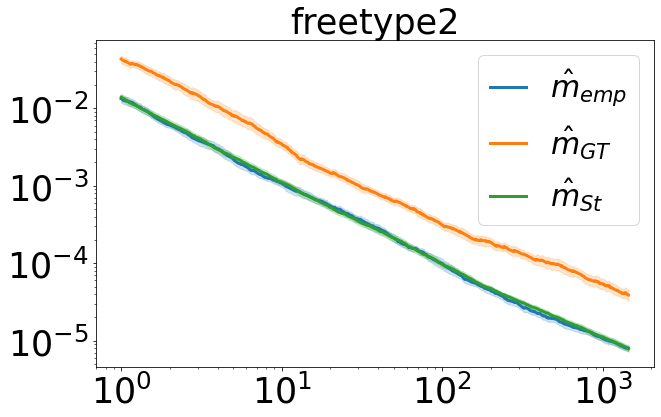

subject: jsoncpp, plot figures...


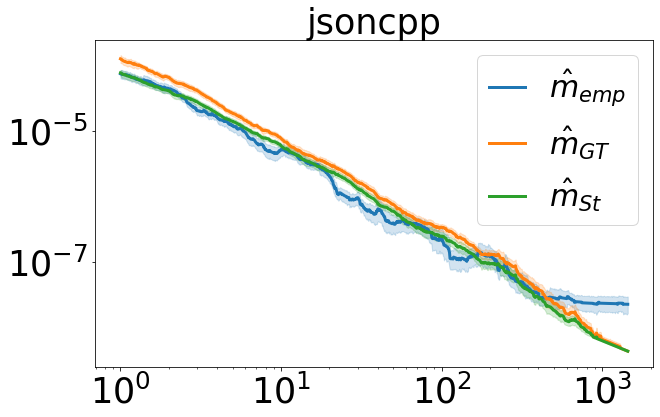

subject: libjpeg, plot figures...


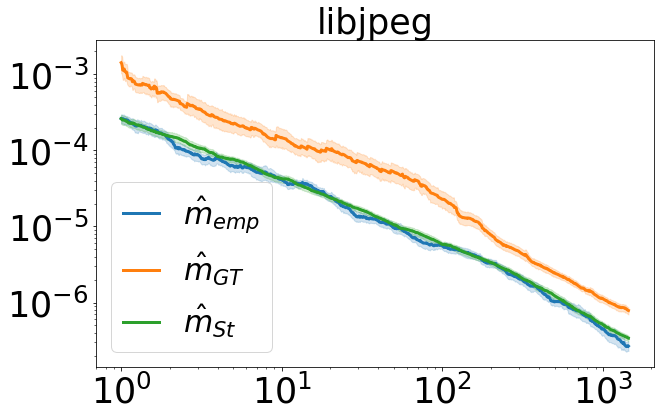

subject: libpcap, plot figures...


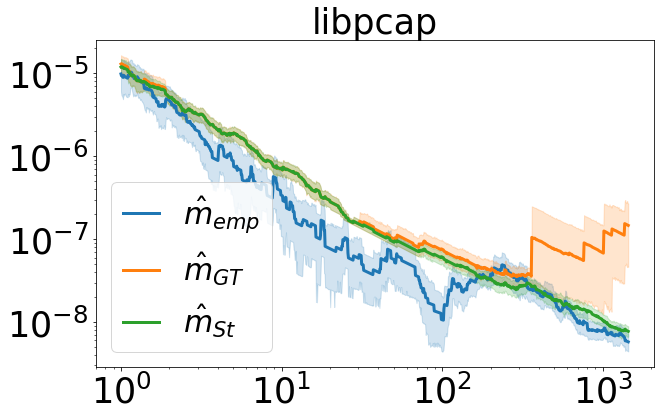

subject: libpng, plot figures...


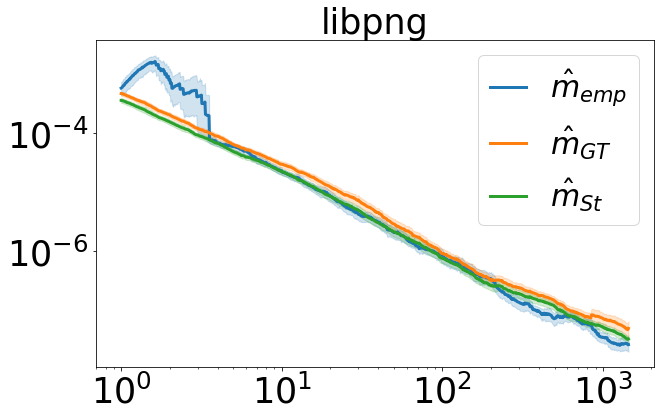

subject: libxml2, plot figures...


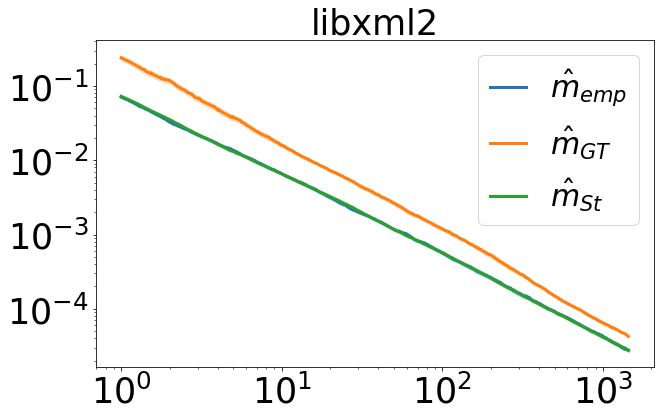

subject: sqlite3, plot figures...


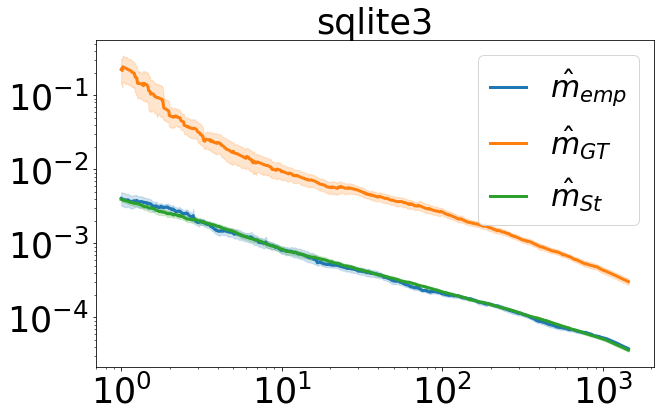

subject: zlib, plot figures...


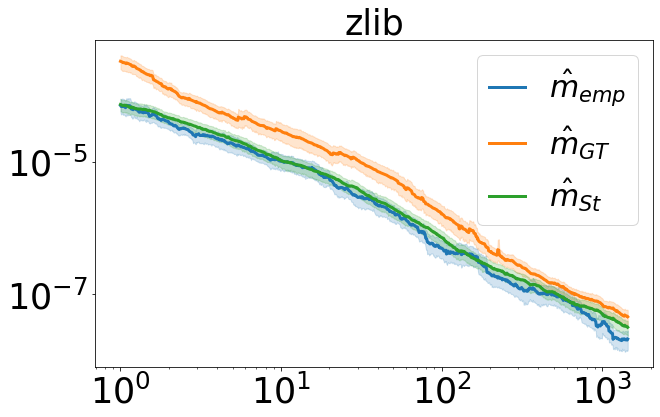

In [14]:
draw_figure = True
if draw_figure:
    for subject in subjects:
        plot_df = pd.read_csv(
            os.path.join(directory, "records/", f"{subject}.csv")
        )
        print(f"subject: {subject}, plot figures...")

        # Probability plot
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(
            x=plot_df["time"].values,
            y=plot_df["Pr"].values,
            hue=plot_df["Esti"].values,
            data=plot_df,
            ax=ax,
            linewidth=3,
        )
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.tick_params(axis="both", labelsize=35)
        # ax.get_legend().remove()
        ax.legend(
            fontsize=30,
            #   shorter line
            handlelength=1.2,
        )
        ax.set_title(subject, fontsize=35)
        plt.savefig(
            os.path.join(fig_dir, f"dp_{subject}.pdf"),
            bbox_inches="tight",
        )
        plt.show()

## Stop time estimation accuracy (RQ1-2.)

It generates

- Boxplot of the observed empirical discovery probabilities during the fuzzing process (Figure 2 in the supplementary material)
- Stop time estimation accuracy (Table 3 in the main paper)

### Boxplot of the observed empirical discovery probabilities during the fuzzing process (Figure 2 in the supplementary material)

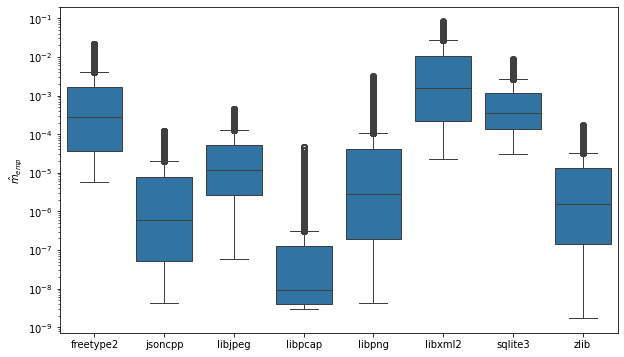

In [15]:
dfs = []
for subject in subjects:
    plot_df = pd.read_csv(os.path.join(directory, f"records/{subject}.csv"))
    sub_df = plot_df[plot_df["Esti"] == r"$\hat{m}_{emp}$"][["Pr"]]
    sub_df["subject"] = subject
    dfs.append(sub_df)
    # break
df = pd.concat(dfs)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="subject", y="Pr", data=df, ax=ax)
ax.set_ylabel(r"$\hat{m}_{emp}$")
ax.set_xlabel("")
ax.set_yscale("log")
plt.savefig(
    os.path.join(fig_dir, "dp_emp_boxplot.pdf"),
    bbox_inches="tight",
)
plt.show()

In [16]:
# finds the discovery probability threshold time for each subject based on the
# empirical discovery probability observed during the fuzzing campaign
target_ps = [
    0.001,
    0.0001,
    0.00001,
    0.000001,
    0.0000001,
    0.00000001,
    0.000000001,
]
data = []
print("Processing...")
for subject in subjects:
    print(f"{subject=}", flush=True, end=" ")
    plot_df = pd.read_csv(os.path.join(directory, f"records/{subject}.csv"))
    for idx in sorted(plot_df["id"].unique()):
        print(f"{idx}", flush=True, end=" ")
        sub_df = plot_df[plot_df["id"] == idx]
        sub_df_emp = sub_df[sub_df["Esti"] == r"$\hat{m}_{emp}$"]
        sub_df_gt = sub_df[sub_df["Esti"] == r"$\hat{m}_{GT}$"]
        sub_df_chao = sub_df[sub_df["Esti"] == r"$\hat{m}_{St}$"]
        for target_p in target_ps:
            if (
                sub_df_emp["Pr"].min() > target_p
                or sub_df_emp["Pr"].max() < target_p
            ):
                data.append((subject, idx, target_p, np.nan, np.nan, np.nan))
                continue
            for i, row in sub_df_emp.iterrows():
                if row["Pr"] < target_p:
                    break
            emp_time = row["time"]
            if sub_df_gt["Pr"].min() > target_p:
                GT_time = np.inf
            elif sub_df_gt["Pr"].max() < target_p:
                GT_time = -np.inf
            else:
                for i, row in sub_df_gt.iterrows():
                    if row["Pr"] < target_p:
                        break
                GT_time = row["time"]
            if sub_df_chao["Pr"].min() > target_p:
                Chao_time = np.inf
            elif sub_df_chao["Pr"].max() < target_p:
                Chao_time = -np.inf
            else:
                for i, row in sub_df_chao.iterrows():
                    if row["Pr"] < target_p:
                        break
                Chao_time = row["time"]
            data.append((subject, idx, target_p, emp_time, GT_time, Chao_time))
    print()
stop_df = pd.DataFrame(
    data,
    columns=["subject", "id", "target_p", "emp_time", "GT_time", "Chao_time"],
)

# for each subject, target_p, count the number of indices that have non-NaN or
# non-inf emp_time, GT_time, Chao_time
stop_df.groupby(["subject", "target_p"]).agg(
    emp_time_count=("emp_time", lambda x: np.sum(np.isfinite(x))),
    GT_time_count=("GT_time", lambda x: np.sum(np.isfinite(x))),
    Chao_time_count=("Chao_time", lambda x: np.sum(np.isfinite(x))),
).reset_index()

# find number of non-nan values for each (subject, target_p)
analyze_targets = []
for subject in subjects:
    for target_p in target_ps:
        sub_df = stop_df[
            (stop_df["subject"] == subject) & (stop_df["target_p"] == target_p)
        ]
        # if all of emp_time is not nan, analyze this (subject, target_p)
        if not sub_df["emp_time"].isna().any():
            analyze_targets.append((subject, target_p))
# drop 'libpcap 1e-06' and 'libpcap 1e-07' since they are the same as
# 'libpcap 1e-08'
analyze_targets = [
    target
    for target in analyze_targets
    if not (target[0] == "libpcap" and target[1] != 1e-8)
]
print()
print("<subject, target_p> under analysis:")
for target in analyze_targets:
    print(target)

Processing...
subject='freetype2' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='jsoncpp' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='libjpeg' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='libpcap' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='libpng' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='libxml2' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='sqlite3' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
subject='zlib' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

<subject, target_p> under analysis:
('freetype2', 0.001)
('freetype2', 0.0001)
('jsoncpp', 1e-05)
('jsoncpp', 1e-06)
('jsoncpp', 1e-07)
('libjpeg', 0.0001)
('libjpeg', 1e-05)
('libjpeg', 1e-06)
('libpcap', 1e-08)
('libpng', 0.0001)
('libpng', 1e-05)
('libpng', 1e-06)
('libpng', 1e-07)
('libxml2', 0.001)
('libxml2', 0.0001)
('sqlite3', 0.001)
('sqlite3', 0.0001)
('zlib', 1e-05)
('zlib', 1e-06)
('zlib', 1e-07)


In [17]:
stop_df

,subject,id,target_p,emp_time,GT_time,Chao_time
0,freetype2,1,1.000000e-03,10.576300,25.706308,11.129213
1,freetype2,1,1.000000e-04,86.070177,335.782214,92.569504
2,freetype2,1,1.000000e-05,1084.084301,inf,1015.334958
3,freetype2,1,1.000000e-06,NaN,NaN,NaN
4,freetype2,1,1.000000e-07,NaN,NaN,NaN
...,...,...,...,...,...,...
1115,zlib,20,1.000000e-05,7.138574,27.647442,9.551519
1116,zlib,20,1.000000e-06,47.381383,104.004546,104.004546
1117,zlib,20,1.000000e-07,229.963251,575.453805,575.453805
1118,zlib,20,1.000000e-08,NaN,NaN,NaN


In [18]:
data = []
for subject, target_p in analyze_targets:
    sub_df = stop_df[
        (stop_df["subject"] == subject) & (stop_df["target_p"] == target_p)
    ]
    emp_time = sub_df["emp_time"].median()
    gt_times = sub_df["GT_time"].values
    # change inf to 24 * 60
    gt_times[np.isinf(gt_times)] = 24 * 60
    gt_time = np.median(gt_times)
    chao_times = sub_df["Chao_time"].values
    chao_times[np.isinf(chao_times)] = 24 * 60
    chao_time = np.median(chao_times)
    data.append((subject, target_p, emp_time, gt_time, chao_time))
result_df = pd.DataFrame(
    data,
    columns=[
        "subject",
        "target_p",
        "emp_time",
        "GT_time",
        "Chao_time",
    ],
)
result_df["Err_GT"] = np.abs(result_df["GT_time"] - result_df["emp_time"])
result_df["Err_Chao"] = np.abs(result_df["Chao_time"] - result_df["emp_time"])
result_df["RelErr_GT"] = result_df["Err_GT"] / result_df["emp_time"]
result_df["RelErr_Chao"] = result_df["Err_Chao"] / result_df["emp_time"]
result_df["Ratio"] = result_df["RelErr_Chao"] / result_df["RelErr_GT"]
result_df.columns = [
    "subject",
    r"$m_{\mathit{thres}}$",
    r"$T_{\mathit{emp}}$",
    r"$T_{G}$",
    r"$T_{D}$",
    r"$\mathit{AE}_{G}^{T}$",
    r"$\mathit{AE}_{D}^{T}$",
    r"$\mathit{RE}_{G}^{T}$",
    r"$\mathit{RE}_{D}^{T}$",
    r"$\frac{\mathit{RE}_{D}^{T}}{\mathit{RE}_{G}^{T}}$",
]
display(result_df)

# statistics of RelErr_GT and RelErr_Chao
display(
    result_df[[r"$\mathit{RE}_{D}^{T}$", r"$\mathit{RE}_{G}^{T}$"]].describe()
)


,subject,$m_{\mathit{thres}}$,$T_{\mathit{emp}}$,$T_{G}$,$T_{D}$,$\mathit{AE}_{G}^{T}$,$\mathit{AE}_{D}^{T}$,$\mathit{RE}_{G}^{T}$,$\mathit{RE}_{D}^{T}$,$\frac{\mathit{RE}_{D}^{T}}{\mathit{RE}_{G}^{T}}$
0,freetype2,1.000000e-03,9.763444,26.756603,10.700993,16.993159,0.937549,1.740488,0.096026,0.055172
1,freetype2,1.000000e-04,92.571957,354.645955,92.233790,262.073997,0.338167,2.831030,0.003653,0.001290
2,jsoncpp,1.000000e-05,5.296500,7.484525,6.193906,2.188025,0.897406,0.413108,0.169434,0.410144
3,jsoncpp,1.000000e-06,21.119253,40.519199,34.647644,19.399946,13.528390,0.918591,0.640571,0.697342
4,jsoncpp,1.000000e-07,81.653001,189.628646,163.334647,107.975645,81.681646,1.322372,1.000351,0.756482
5,libjpeg,1.000000e-04,2.116647,9.277647,2.947896,7.161000,0.831249,3.383181,0.392720,0.116080
6,libjpeg,1.000000e-05,42.328219,160.691862,50.971396,118.363643,8.643177,2.796329,0.204194,0.073022
7,libjpeg,1.000000e-06,469.352679,1064.540337,571.658367,595.187658,102.305688,1.268103,0.217972,0.171888
8,libpcap,1.000000e-08,1.640702,780.694598,567.151291,779.053896,565.510590,474.829664,344.676029,0.725894
9,libpng,1.000000e-04,2.916944,3.601901,2.873869,0.684957,0.043075,0.234820,0.014767,0.062887


,$\mathit{RE}_{D}^{T}$,$\mathit{RE}_{G}^{T}$
count,20.000000,20.000000
mean,17.542614,27.754355
std,77.000047,105.891995
min,0.003653,0.234820
25%,0.087004,0.729287
50%,0.186814,1.295238
75%,0.466116,2.805005
max,344.676029,474.829664
